# 🚗 Car Price Prediction — Enhanced Version

**Improvements over original notebook:**
- ➕ Two new input features: `transmission` and `fuel` type
- ➕ Two new regression models: **Gradient Boosting** and **Ridge Regression**
- ✅ Total features used: 5 (year, engine, mileage, transmission, fuel)
- ✅ Total models compared: 6 (Linear Regression + 5 others)

---
### 🧰 Step 1: Setup and Import Libraries

In [1]:
import pandas as pd                        
import numpy as np                           
import matplotlib.pyplot as plt              
import seaborn as sns                        
#import warnings
#warnings.filterwarnings('ignore')

# sklearn — model training, splitting, scaling, evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge         
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


---
### 📦 Step 2: Load the Dataset

In [2]:
file_path = "pakwheels_used_car_data_v02.csv"
df_raw = pd.read_csv(file_path)

print(f"Dataset shape: {df_raw.shape}")
df_raw.head(4)

Dataset shape: (77878, 14)


,addref,city,assembly,body,make,model,year,engine,transmission,fuel,color,registered,mileage,price
0,7943732,Peshawar,NaN,Sedan,Toyota,Corolla,2013.0,1300.0,Manual,Petrol,Silver Metallic,Lahore,145000,2870000.0
1,7730314,Lahore,NaN,Sedan,Honda,City,2000.0,1300.0,Manual,Petrol,Blue,Lahore,230000,995000.0
2,7943737,Lahore,NaN,Sedan,Toyota,Yaris,2021.0,1300.0,Manual,Petrol,Super White,Punjab,60500,3585000.0
3,7943733,Lahore,NaN,Hatchback,Suzuki,Swift,2017.0,1300.0,Manual,Petrol,Grey,Islamabad,87000,2250000.0


---
### 🔍 Step 3: Exploratory Data Analysis (EDA)

In [3]:
# Shape, data types, and null counts
print(f"Rows and Columns: {df_raw.shape}")
df_raw.info()

Rows and Columns: (77878, 14)
<class 'pandas.DataFrame'>
RangeIndex: 77878 entries, 0 to 77877
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   addref        77878 non-null  int64  
 1   city          77878 non-null  str    
 2   assembly      24189 non-null  str    
 3   body          68974 non-null  str    
 4   make          77878 non-null  str    
 5   model         77878 non-null  str    
 6   year          73099 non-null  float64
 7   engine        77875 non-null  float64
 8   transmission  77878 non-null  str    
 9   fuel          76972 non-null  str    
 10  color         76398 non-null  str    
 11  registered    77878 non-null  str    
 12  mileage       77878 non-null  int64  
 13  price         77295 non-null  float64
dtypes: float64(3), int64(2), str(9)
memory usage: 8.3 MB


In [4]:
# Statistical summary of all numeric columns
df_raw.describe()

,addref,year,engine,mileage,price
count,7.787800e+04,73099.000000,77875.000000,77878.000000,7.729500e+04
mean,7.809878e+06,2012.812610,1408.072550,91109.192750,3.883232e+06
std,2.599523e+05,7.516685,704.459947,89275.336173,5.759480e+06
min,2.748970e+05,1990.000000,3.000000,1.000000,1.100000e+05
25%,7.805760e+06,2007.000000,1000.000000,34000.000000,1.450000e+06
50%,7.865805e+06,2015.000000,1300.000000,80000.000000,2.700000e+06
75%,7.910334e+06,2019.000000,1600.000000,123456.000000,4.500000e+06
max,7.943741e+06,2022.000000,15000.000000,1000000.000000,5.290000e+08


In [5]:
# Count of missing values per column
print("Missing values per column:")
df_raw.isnull().sum()

Missing values per column:


addref              0
city                0
assembly        53689
body             8904
make                0
model               0
year             4779
engine              3
transmission        0
fuel              906
color            1480
registered          0
mileage             0
price             583
dtype: int64

In [6]:
# Explore the two NEW categorical features we are adding
print("Transmission value counts:")
print(df_raw['transmission'].value_counts())
print()
print("Fuel type value counts:")
print(df_raw['fuel'].value_counts())

Transmission value counts:
transmission
Automatic    42763
Manual       35115
Name: count, dtype: int64

Fuel type value counts:
fuel
Petrol    70620
Diesel     3457
Hybrid     2895
Name: count, dtype: int64


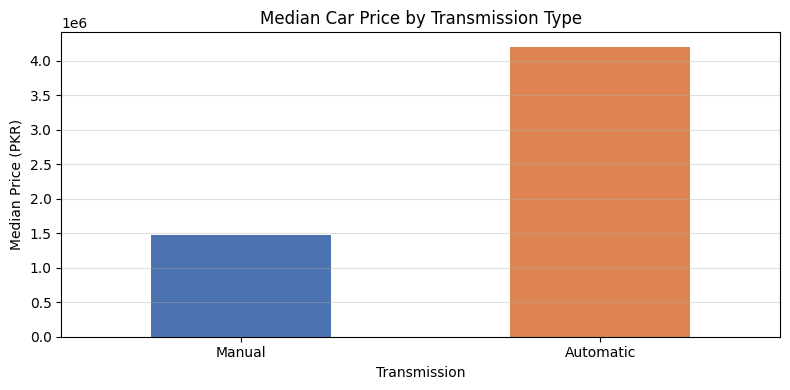

In [7]:
# Visualise average price by transmission type
plt.figure(figsize=(8, 4))
df_raw.groupby('transmission')['price'].median().sort_values().plot(kind='bar', color=['#4C72B0','#DD8452'])
plt.title('Median Car Price by Transmission Type')
plt.ylabel('Median Price (PKR)')
plt.xlabel('Transmission')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

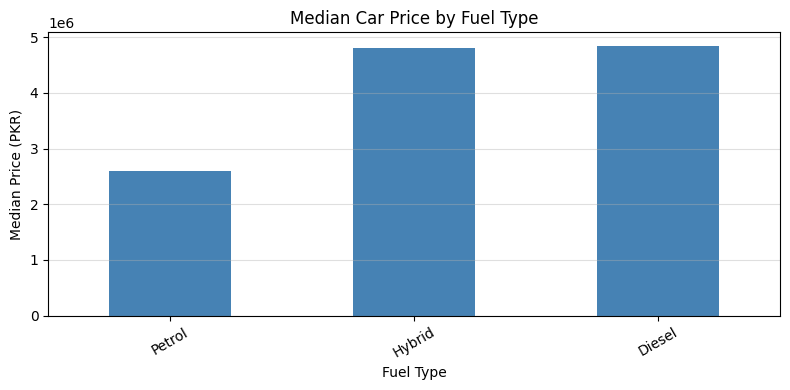

In [8]:
# Visualise average price by fuel type
plt.figure(figsize=(8, 4))
df_raw.groupby('fuel')['price'].median().sort_values().plot(kind='bar', color='steelblue')
plt.title('Median Car Price by Fuel Type')
plt.ylabel('Median Price (PKR)')
plt.xlabel('Fuel Type')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

---
### 🛠️ Step 4: Data Preprocessing

**Original features:** `year`, `engine`, `mileage`  
**NEW features added:** `transmission` (Automatic=1, Manual=0), `fuel` (Petrol=0, Diesel=1, Hybrid=2, …)

In [9]:
# --- Select the features we want to use ---
input_features = ['year', 'engine', 'mileage', 'transmission', 'fuel', 'price']
df = df_raw[input_features].copy()

print("Selected features:")
df.head(4)

Selected features:


,year,engine,mileage,transmission,fuel,price
0,2013.0,1300.0,145000,Manual,Petrol,2870000.0
1,2000.0,1300.0,230000,Manual,Petrol,995000.0
2,2021.0,1300.0,60500,Manual,Petrol,3585000.0
3,2017.0,1300.0,87000,Manual,Petrol,2250000.0


In [10]:
# Check missing values in selected columns
print("Missing values in selected features:")
print(df.isnull().sum())

Missing values in selected features:
year            4779
engine             3
mileage            0
transmission       0
fuel             906
price            583
dtype: int64


In [11]:
# --- NEW FEATURE 1: Encode 'transmission' ---
# Automatic = 1, Manual = 0  (binary encoding)
df['transmission_enc'] = (df['transmission'] == 'Automatic').astype(int)

# --- NEW FEATURE 2: Encode 'fuel' ---
# Map each fuel type to a numeric code
fuel_map = {'Petrol': 0, 'Diesel': 1, 'Hybrid': 2, 'LPG': 3, 'CNG': 4, 'Electric': 5}
df['fuel_enc'] = df['fuel'].map(fuel_map).fillna(0).astype(int)

print("Encoded transmission sample:")
print(df[['transmission', 'transmission_enc']].value_counts().head())
print()
print("Encoded fuel sample:")
print(df[['fuel', 'fuel_enc']].value_counts().head())

Encoded transmission sample:
transmission  transmission_enc
Automatic     1                   42763
Manual        0                   35115
Name: count, dtype: int64

Encoded fuel sample:
fuel    fuel_enc
Petrol  0           70620
Diesel  1            3457
Hybrid  2            2895
Name: count, dtype: int64


In [12]:
# --- Drop rows with any remaining missing values ---
df.dropna(inplace=True)
print(f"Rows after dropping nulls: {len(df)}")
print("Missing values remaining:", df.isnull().sum().sum())

Rows after dropping nulls: 71955
Missing values remaining: 0


In [13]:
# --- Separate features (X) and target label (y) ---
# 5 input features: year, engine, mileage, transmission_enc, fuel_enc
X = df[['year', 'engine', 'mileage', 'transmission_enc', 'fuel_enc']]
y = df['price']

print("Feature matrix X shape:", X.shape)
print("Target vector y shape: ", y.shape)
print()
print("Features used:")
print(X.columns.tolist())

Feature matrix X shape: (71955, 5)
Target vector y shape:  (71955,)

Features used:
['year', 'engine', 'mileage', 'transmission_enc', 'fuel_enc']


In [14]:
# --- Feature Scaling (StandardScaler) ---
# Transforms each feature to mean=0, std=1
# This is important for distance-based models (KNN, SVR) and gradient-based models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling complete. Sample of scaled values:")
print(pd.DataFrame(X_scaled, columns=X.columns).head(3).round(3))

Scaling complete. Sample of scaled values:
    year  engine  mileage  transmission_enc  fuel_enc
0  0.018  -0.141    0.610             -1.11    -0.272
1 -1.725  -0.141    1.608             -1.11    -0.272
2  1.090  -0.141   -0.382             -1.11    -0.272


---
### 🔄 Step 5: Train-Test Split

In [15]:
# 80% training data, 20% test data
# random_state=42 ensures reproducible results
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set size : {X_train.shape[0]} rows × {X_train.shape[1]} features")
print(f"Test set size     : {X_test.shape[0]} rows × {X_test.shape[1]} features")

Training set size : 57564 rows × 5 features
Test set size     : 14391 rows × 5 features


---
### ✅ Step 6: Train Linear Regression (Baseline Model)

In [16]:
# --- Linear Regression (baseline) ---
lr = LinearRegression()     # initialise
lr.fit(X_train, y_train)    # train on training data

# Evaluate on test data
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

print(f"Linear Regression (5 features)")
print(f"  Mean Squared Error : {mse_lr:.2f}")
print(f"  R² Score           : {r2_lr:.4f}")

# Show feature coefficients — tells us the weight of each feature
coeff_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_})
print()
print("Feature coefficients:")
print(coeff_df.sort_values('Coefficient', key=abs, ascending=False))

Linear Regression (5 features)
  Mean Squared Error : 13459090152623.62
  R² Score           : 0.4545

Feature coefficients:
            Feature   Coefficient
1            engine  2.810611e+06
0              year  1.558131e+06
3  transmission_enc  4.239688e+05
2           mileage -3.238016e+05
4          fuel_enc  3.946421e+04


---
### 📈 Step 7: Visualise Predictions — Linear Regression

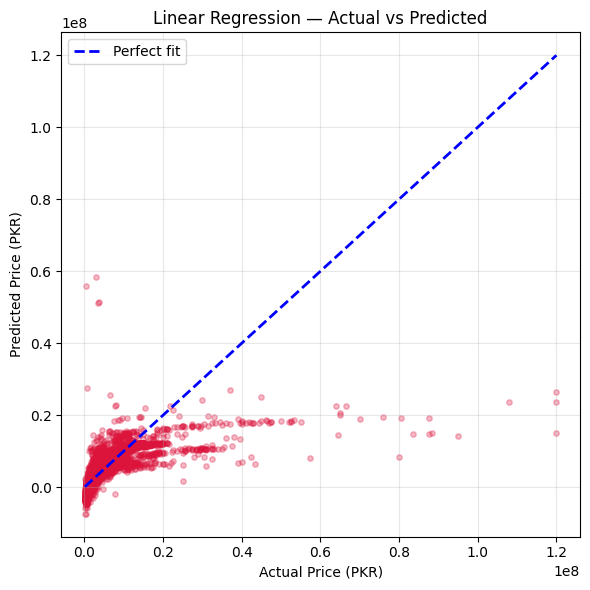

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.3, c='crimson', s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', linewidth=2, label='Perfect fit')
plt.xlabel("Actual Price (PKR)")
plt.ylabel("Predicted Price (PKR)")
plt.title("Linear Regression — Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
### 🧠 Step 8: Train All 5 Additional Models

| Model | Type | Notes |
|---|---|---|
| Decision Tree | Original | Rule-based splits |
| Random Forest | Original | Ensemble of trees |
| KNN | Original | Distance-based |
| SVR | Original | Support Vector Machine |
| **Gradient Boosting** | ✅ **NEW** | Sequential error correction |
| **Ridge Regression** | ✅ **NEW** | L2 regularised linear model |

In [18]:
# --- Dictionary of all models to train and compare ---
models = {
    "Decision Tree"      : DecisionTreeRegressor(random_state=42),
    "Random Forest"      : RandomForestRegressor(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "SVR"                : SVR(kernel='rbf'),

    # ── NEW MODEL 1: Gradient Boosting ───────────────────────────────
    # Builds trees sequentially — each tree corrects errors of the previous one.
    # Great for tabular data, usually outperforms Random Forest on structured datasets.
    "Gradient Boosting"  : GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),

    # ── NEW MODEL 2: Ridge Regression ────────────────────────────────
    # Linear regression with L2 regularisation (alpha controls strength).
    # Prevents overfitting when features are correlated. Keeps all coefficients.
    "Ridge Regression"   : Ridge(alpha=1.0),
}

# --- Train each model, predict, and record metrics ---
results = {}

print(f"{'Model':<25} {'MSE':>20} {'R² Score':>10}")
print("-" * 60)

for name, model in models.items():
    model.fit(X_train, y_train)          # train
    y_pred = model.predict(X_test)       # predict
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    results[name] = {'mse': mse, 'r2': r2, 'y_pred': y_pred}
    print(f"{name:<25} {mse:>20.2f} {r2:>10.4f}")

Model                                      MSE   R² Score
------------------------------------------------------------
Decision Tree                 7670265094983.46     0.6891
Random Forest                 5410289856619.96     0.7807
K-Nearest Neighbors           5794350864701.55     0.7652
SVR                          25718333741526.10    -0.0423
Gradient Boosting             5460100715075.10     0.7787
Ridge Regression             13459083124129.88     0.4545


---
### 📊 Step 9: Compare All Models — R² Score Bar Chart

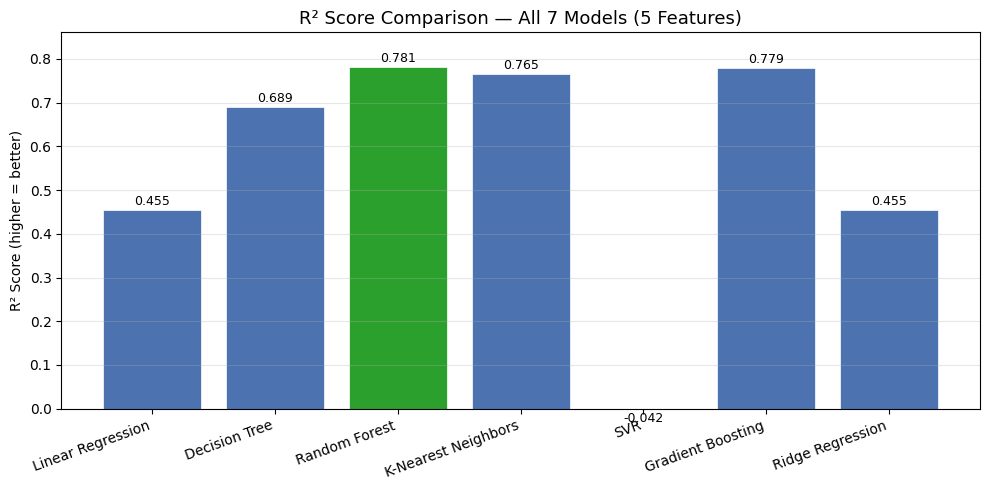


Best model: Random Forest  (R² = 0.7807)


In [19]:
# Compile full results including Linear Regression
all_results = {'Linear Regression': {'r2': r2_lr}}
all_results.update({k: {'r2': v['r2']} for k, v in results.items()})

names  = list(all_results.keys())
r2_vals = [all_results[n]['r2'] for n in names]

# Color best models differently
colors = ['#4C72B0' if r < max(r2_vals) else '#2ca02c' for r in r2_vals]

plt.figure(figsize=(10, 5))
bars = plt.bar(names, r2_vals, color=colors, edgecolor='white', linewidth=0.5)

# Add value labels on bars
for bar, val in zip(bars, r2_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.title('R² Score Comparison — All 7 Models (5 Features)', fontsize=13)
plt.ylabel('R² Score (higher = better)')
plt.ylim(0, max(r2_vals) + 0.08)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best = max(all_results, key=lambda k: all_results[k]['r2'])
print(f"\nBest model: {best}  (R² = {all_results[best]['r2']:.4f})")

---
### 📉 Step 10: Actual vs Predicted — All Models Side by Side

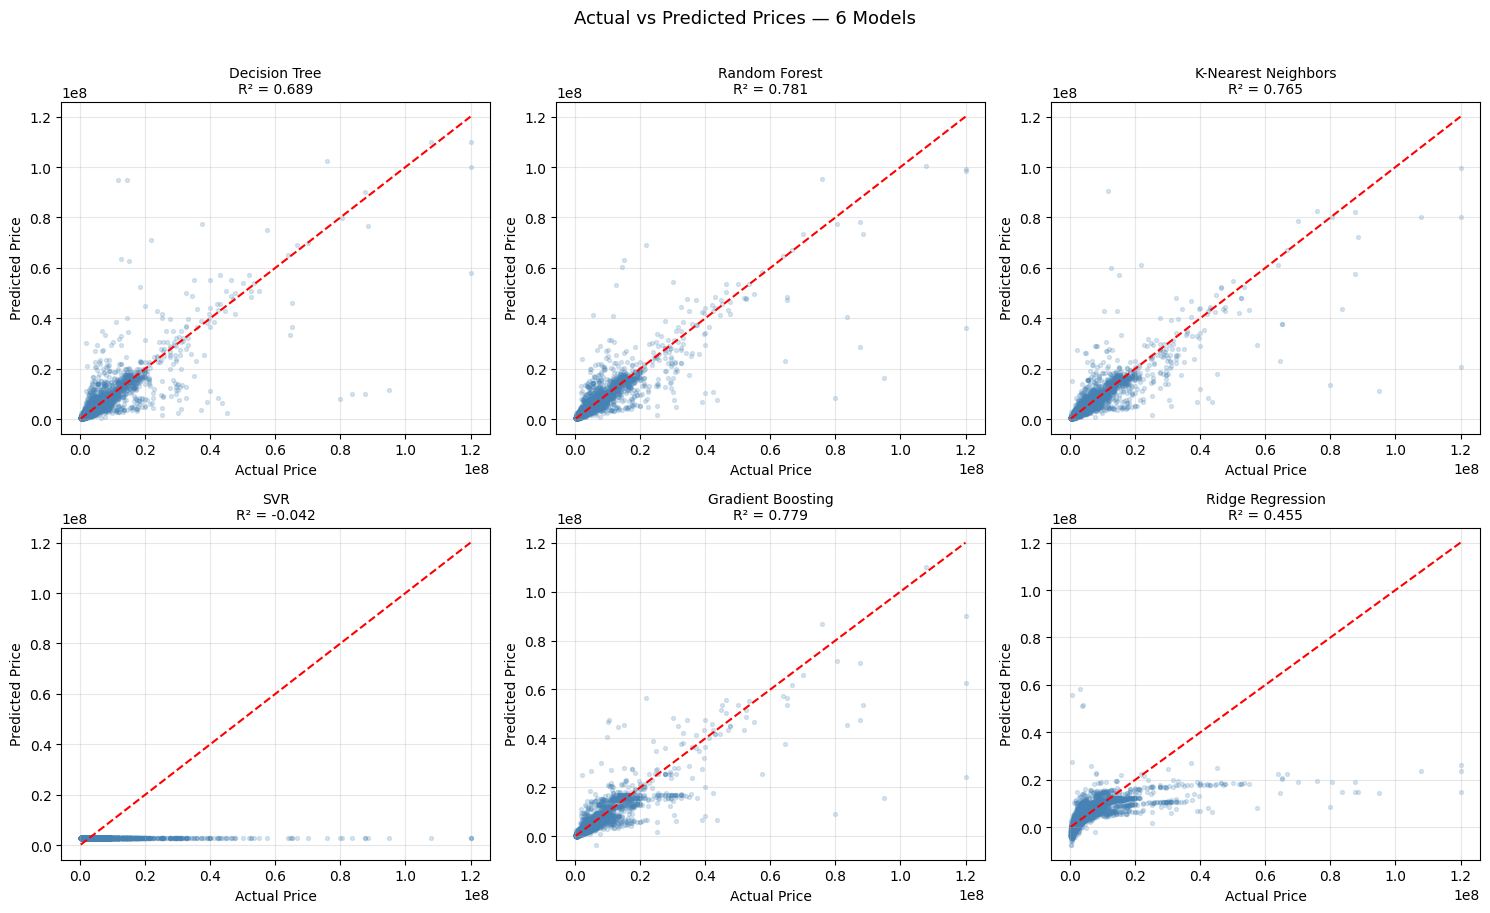

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

plot_models = list(results.items())   # the 6 additional models

for ax, (name, res) in zip(axes, plot_models):
    ax.scatter(y_test, res['y_pred'], alpha=0.2, s=8, color='steelblue')
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_title(f"{name}\nR² = {res['r2']:.3f}", fontsize=10)
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.grid(alpha=0.3)

plt.suptitle('Actual vs Predicted Prices — 6 Models', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
### 🔬 Step 11: Feature Importance — Gradient Boosting (NEW Model)

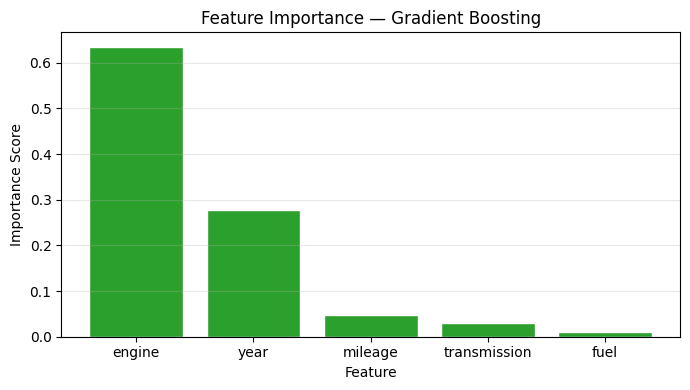

  engine          : 0.6350
  year            : 0.2769
  mileage         : 0.0474
  transmission    : 0.0301
  fuel            : 0.0106


In [21]:
# Gradient Boosting provides native feature importance scores
gb_model   = models['Gradient Boosting']
feat_names = ['year', 'engine', 'mileage', 'transmission', 'fuel']
importances = gb_model.feature_importances_

# Sort for clear visualisation
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(7, 4))
plt.bar([feat_names[i] for i in sorted_idx],
        importances[sorted_idx],
        color='#2ca02c', edgecolor='white')
plt.title('Feature Importance — Gradient Boosting', fontsize=12)
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for i in sorted_idx:
    print(f"  {feat_names[i]:<15} : {importances[i]:.4f}")

---
### 🔬 Step 12: Ridge vs Linear Regression — Coefficient Comparison (NEW Model)

Coefficient comparison:
     Feature  Linear Regression    Ridge (L2)
        year       1.558131e+06  1.558091e+06
      engine       2.810611e+06  2.810550e+06
     mileage      -3.238016e+05 -3.238075e+05
transmission       4.239688e+05  4.239887e+05
        fuel       3.946421e+04  3.947351e+04


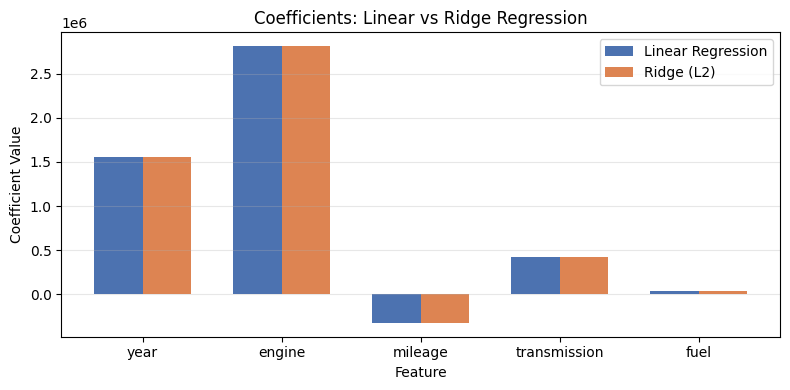

In [22]:
# Compare coefficients from Linear Regression vs Ridge Regression
ridge_model = models['Ridge Regression']
feat_names  = ['year', 'engine', 'mileage', 'transmission', 'fuel']

coeff_compare = pd.DataFrame({
    'Feature'           : feat_names,
    'Linear Regression' : lr.coef_,
    'Ridge (L2)'        : ridge_model.coef_
})

print("Coefficient comparison:")
print(coeff_compare.to_string(index=False))

# Bar chart comparison
x  = np.arange(len(feat_names))
w  = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - w/2, coeff_compare['Linear Regression'], w, label='Linear Regression', color='#4C72B0')
plt.bar(x + w/2, coeff_compare['Ridge (L2)'],        w, label='Ridge (L2)',        color='#DD8452')
plt.xticks(x, feat_names)
plt.title('Coefficients: Linear vs Ridge Regression', fontsize=12)
plt.ylabel('Coefficient Value')
plt.xlabel('Feature')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
### 🧪 Step 13: Test on a Single Sample

In [23]:
# Take one test sample and compare predictions from all models
sample_idx = 101
sample_X   = X_test[sample_idx].reshape(1, -1)
actual     = y_test.iloc[sample_idx]

print(f"Sample index    : {sample_idx}")
print(f"Actual price    : PKR {actual:,.0f}")
print()
print(f"{'Model':<25} {'Predicted Price':>18} {'Error':>15}")
print("-" * 62)

# Linear Regression
pred_lr = lr.predict(sample_X)[0]
print(f"{'Linear Regression':<25} PKR {pred_lr:>12,.0f} {abs(pred_lr-actual)/actual*100:>13.1f}%")

# All other models
for name, model in models.items():
    pred = model.predict(sample_X)[0]
    err  = abs(pred - actual) / actual * 100
    print(f"{name:<25} PKR {pred:>12,.0f} {err:>13.1f}%")

Sample index    : 101
Actual price    : PKR 12,000,000

Model                        Predicted Price           Error
--------------------------------------------------------------
Linear Regression         PKR    6,084,200          49.3%
Decision Tree             PKR   11,500,000           4.2%
Random Forest             PKR    9,493,307          20.9%
K-Nearest Neighbors       PKR    6,997,000          41.7%
SVR                       PKR    2,723,446          77.3%
Gradient Boosting         PKR    5,077,961          57.7%
Ridge Regression          PKR    6,084,170          49.3%


---
### 📋 Step 14: Final Summary Table

In [24]:
# Complete summary of all models
summary_data = [{'Model': 'Linear Regression', 'R² Score': r2_lr,
                 'MSE': mse_lr, 'Type': 'Linear', 'New': ''}]

for name, res in results.items():
    mtype = 'Ensemble' if 'Forest' in name or 'Boosting' in name else \
            'Tree'     if 'Tree'   in name else \
            'Instance' if 'Neighbor' in name else \
            'SVM'      if name == 'SVR' else 'Linear'
    is_new = '✅ NEW' if name in ['Gradient Boosting', 'Ridge Regression'] else ''
    summary_data.append({'Model': name, 'R² Score': res['r2'],
                         'MSE': res['mse'], 'Type': mtype, 'New': is_new})

summary_df = pd.DataFrame(summary_data).sort_values('R² Score', ascending=False).reset_index(drop=True)
summary_df['R² Score'] = summary_df['R² Score'].round(4)
summary_df['MSE']      = summary_df['MSE'].apply(lambda x: f"{x:.2e}")

print("=" * 70)
print("FINAL MODEL COMPARISON — Car Price Prediction (5 Features)")
print("=" * 70)
print(summary_df.to_string(index=True))
print()
print(f"Features used: year, engine, mileage, transmission (NEW), fuel (NEW)")
print(f"Training samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")

FINAL MODEL COMPARISON — Car Price Prediction (5 Features)
                 Model  R² Score       MSE      Type    New
0        Random Forest    0.7807  5.41e+12  Ensemble       
1    Gradient Boosting    0.7787  5.46e+12  Ensemble  ✅ NEW
2  K-Nearest Neighbors    0.7652  5.79e+12  Instance       
3        Decision Tree    0.6891  7.67e+12      Tree       
4     Ridge Regression    0.4545  1.35e+13    Linear  ✅ NEW
5    Linear Regression    0.4545  1.35e+13    Linear       
6                  SVR   -0.0423  2.57e+13       SVM       

Features used: year, engine, mileage, transmission (NEW), fuel (NEW)
Training samples: 57564 | Test samples: 14391
